In [1]:
import pandas as pd

In [3]:
df=pd.read_csv("C:\\Users\\Admin\\Desktop\\Titanic-Dataset.csv")


# Data Exploration

In [4]:
df.shape

(891, 12)

In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Data Cleaning

### Remove Null Values

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df=df.drop("Cabin",axis=1)

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [13]:
df["Age"].skew()

np.float64(0.38910778230082704)

In [14]:
df["Age"]=df["Age"].fillna(df["Age"].mean())

In [15]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [16]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

In [17]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# Duplicate Values

In [20]:
print(df.duplicated().sum())

0


# Outlier Analysis

In [24]:
import numpy as np
a=df.select_dtypes(include=np.number)

In [22]:
import seaborn as sns

<Axes: >

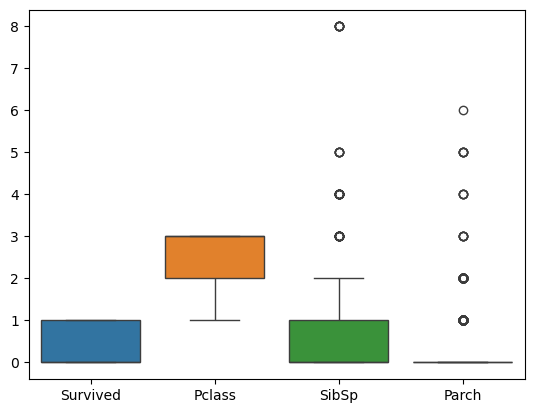

In [23]:
sns.boxplot([df["Survived"],df["Pclass"],df["SibSp"],df["Parch"]])

# IQR

In [25]:
for i in a:
    q1=a[i].quantile(0.25)
    q2=a[i].quantile(0.50)
    q3=a[i].quantile(0.75)

In [28]:
IQR=q3-q1

In [29]:
Uw=q3+1.5*IQR
Lw=q1-1.5*IQR

In [33]:
outliers=((a[i]>Uw)|(a[i]<Lw))

In [31]:
print(outliers.sum())

116


In [32]:
a.loc[(a[i]>Uw)|(a[i]<Lw),i]=q2

In [34]:
print(outliers.sum())

0
